# 04 · Level-1 heads on frozen features

Each "view" (a feature block) gets small, strongly regularised regressors. Everything here follows what the leaderboard taught us:

| Lesson | Evidence | Consequence here |
|---|---|---|
| The metric is **0.6·RMSE + 0.4·(1 − Pearson)** | 5 diagnostic submissions; misfit 0.0003 vs 0.033 for the 50/50 form | all scores use it (`metrics.composite`) |
| **> 50% of test answers prompts that are ~absent from train** | topic clusters: "free time / family" is 43% of test vs 3% of train, "floods" 10% vs 1% | **folds hold out speakers *and* prompts** (`folds_joint.csv`), so the stack learns how views transfer to new prompts |
| Test clips are shorter (~45 s vs ~60 s) | duration audit; a top team gained 0.3454 → 0.3350 by training on test-length crops | **every head trains on full clips + 40–50 s crops**, and is also scored on crops of held-out clips (`composite_short`) |
| Population weights / calibration hurt on the LB | run 3 (0.3895 vs 0.3800); same for other teams | plain label-rarity weights, no population terms |

Views: four frozen speech encoders (two layer bands each, ridge + RBF-SVR), transcript features (ridge / SVR / LightGBM), Qwen3 hidden states (1.7B and 4B; Whisper and CTC text), and TF-IDF n-grams of the error-preserving CTC transcript.

In [1]:
import os, sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
for p in Path("/kaggle/input").glob("*/src"):
    sys.path.insert(0, str(p))
from shl import embed, heads, metrics

OUT = Path("/kaggle/working") if Path("/kaggle/working").exists() else ROOT / "artifacts"
FEAT, PRED, TXT = OUT / "features", OUT / "preds", OUT / "text"
PRED.mkdir(exist_ok=True)
for f in PRED.glob("*.npz"):          # fresh run: no stale predictions in the stack
    if "_adapter__" not in f.stem:    # adapter heads come from notebook 06
        f.unlink()
sns.set_theme(style="whitegrid")

meta = pd.read_csv(OUT / "meta.csv")
fold_df = pd.read_csv(OUT / "folds_joint.csv")             # speaker + prompt held out
folds = fold_df.drop(columns="uid")
row_of = {u: i for i, u in enumerate(meta.uid)}
fit_rows = np.array([row_of[u] for u in fold_df.uid])
test_rows = np.where(meta.split == "test")[0]
y = meta.label.values[fit_rows]
groups = meta.group.values[fit_rows]                       # inner CV stays speaker-grouped
w = heads.sample_weights(y, power=0.5)

crops = pd.read_csv(FEAT / "crops.csv")
pos_in_fit = {u: i for i, u in enumerate(fold_df.uid)}
crop_keep = crops.uid.isin(pos_in_fit).values
crop_src = np.array([pos_in_fit[u] for u in crops.uid[crop_keep]])
print(f"fit clips {len(y)}, test {len(test_rows)}, crops {crop_keep.sum()}; fold sizes {folds.iloc[:, 0].value_counts().sort_index().tolist()}")

fit clips 732, test 216, crops 1464; fold sizes [263, 211, 64, 105, 89]


C:\Users\Tanmay\anaconda3\envs\shl\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1 · Audio band views
Layer bands come from the per-layer profiles (notebook history: WavLM peaks at layers 18–21, Whisper at 29–32).

In [2]:
ENC = list(embed.ENCODERS)
full = {k: np.load(FEAT / f"{k}_full.npy", mmap_mode="r") for k in ENC}
crop = {k: np.load(FEAT / f"{k}_crops.npy", mmap_mode="r") for k in ENC}
profiles = pd.read_csv(OUT / "layer_profiles.csv")
views = {f"{k}_{t}": (k, s, e) for k in ENC for t, (s, e) in zip("AB", heads.bands_for(profiles[profiles.encoder == k]))}
# Lean candidate pool: only views the stack kept in runs 2-3 (the stack pruned 20-26 heads to 5 both times).
AUDIO_HEADS = {"whisper_v3_A": ("ridge", "svr"), "wavlm_large_A": ("ridge", "svr"),
               "hubert_large_B": ("ridge",), "w2vbert2_B": ("ridge", "svr")}
views = {v: views[v] for v in AUDIO_HEADS}
pd.DataFrame([(v, k, f"{s}-{e - 1}") for v, (k, s, e) in views.items()], columns=["view", "encoder", "layers"])

,view,encoder,layers
0,whisper_v3_A,whisper_v3,29-32
1,wavlm_large_A,wavlm_large,18-21
2,hubert_large_B,hubert_large,19-22
3,w2vbert2_B,w2vbert2,16-19


In [3]:
results = []

def save(res, view, head):
    np.savez(PRED / f"{view}__{head}.npz", oof=res.oof, oof_per_seed=res.oof_per_seed, test=res.test,
             insample=res.insample, oof_short=res.oof_short, oof_short_per_seed=res.oof_short_per_seed)
    results.append(res.summary(y))
    print(f"{res.name:30s} full {results[-1]['composite']:.4f} | short {results[-1]['composite_short']:.4f}")

def fit_view(name, X, Xt, Xc, heads_=("ridge", "svr")):
    aug = dict(X_aug=Xc, aug_index=crop_src, X_short=Xc, short_index=crop_src)
    if "ridge" in heads_:
        save(heads.run_fast_ridge(X, y, groups, folds, Xt, w, name=f"{name}__ridge", **aug), name, "ridge")
    for h in [h for h in heads_ if h != "ridge"]:
        save(heads.run_cv(h, X, y, groups, folds, Xt, weights=w, name=f"{name}__{h}", **aug), name, h)

for vk, (k, s, e) in views.items():
    band = lambda a, rows: np.asarray(a[rows, s:e], np.float32).mean(1)
    fit_view(vk, band(full[k], fit_rows), band(full[k], test_rows), np.asarray(crop[k][:, s:e], np.float32).mean(1)[crop_keep],
             heads_=AUDIO_HEADS[vk])

whisper_v3_A__ridge            full 0.4305 | short 0.4268


whisper_v3_A__svr              full 0.4283 | short 0.4209


wavlm_large_A__ridge           full 0.4275 | short 0.4297


wavlm_large_A__svr             full 0.4306 | short 0.4295


hubert_large_B__ridge          full 0.4655 | short 0.4557


w2vbert2_B__ridge              full 0.5084 | short 0.5118


w2vbert2_B__svr                full 0.5235 | short 0.5253


## 2 · Transcript views
Crop rows use the crop's own words (CTC words and Whisper segments inside the crop window), so text heads see test-length transcripts too.

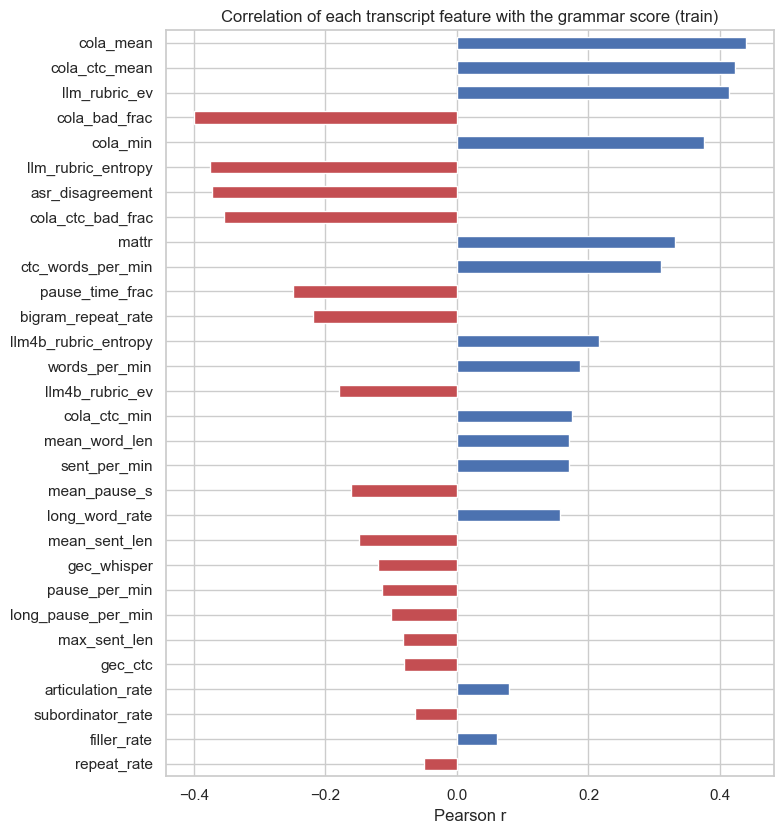

text_hand__svr                 full 0.5830 | short 0.6124


text_hand__lgbm                full 0.5862 | short 0.6147


In [4]:
hand = pd.read_csv(TXT / "hand.csv")
feat_cols = [c for c in hand.columns if c not in ("kind", "uid", "crop_row", "duration_s")]
full_idx = {u: i for i, u in enumerate(hand.uid[hand.kind == "full"])}
crop_idx = dict(zip(hand.crop_row[hand.kind == "crop"].astype(int), np.where(hand.kind == "crop")[0]))
t_fit = np.array([full_idx[u] for u in meta.uid.values[fit_rows]])
t_test = np.array([full_idx[u] for u in meta.uid.values[test_rows]])
t_crop = np.array([crop_idx[r] for r in np.where(crop_keep)[0]])
H = hand[feat_cols].fillna(0).values.astype(np.float32)
corr = pd.Series({c: metrics.pearson(y, H[t_fit, j]) for j, c in enumerate(feat_cols)}).sort_values(key=abs, ascending=False)
fig, ax = plt.subplots(figsize=(8, 0.25 * len(corr) + 1))
corr.plot.barh(ax=ax, color=np.where(corr > 0, "#4c72b0", "#c44e52")); ax.invert_yaxis()
ax.set(title="Correlation of each transcript feature with the grammar score (train)", xlabel="Pearson r")
plt.tight_layout(); plt.show()
fit_view("text_hand", H[t_fit], H[t_test], H[t_crop], heads_=("svr", "lgbm"))

llm: band 16-19


text_llm__ridge                full 0.4692 | short 0.4935


llm4bctc: band 21-24


text_llm4bctc__ridge           full 0.4600 | short 0.4703


enc_deberta_ctc: band 4-7


...

text_enc_electra_whisper__ridge full 0.4519 | short 0.4681


enc_roberta_ctc: band 17-20


text_enc_roberta_ctc__ridge    full 0.4615 | short 0.4778


enc_roberta_whisper: band 19-22


text_enc_roberta_whisper__ridge full 0.4548 | short 0.4765


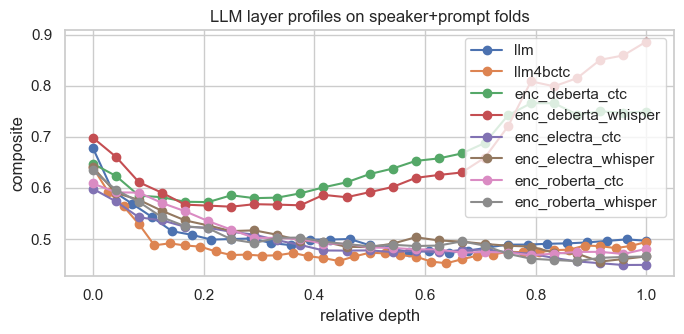

In [5]:
fig, ax = plt.subplots(figsize=(7, 3.5))
# Qwen3 states (1.7B on Whisper text, 4B on CTC text) + frozen text encoders (DeBERTa/RoBERTa/ELECTRA, both transcripts)
for path in [TXT / "llm_states.npy", TXT / "llm4bctc_states.npy"] + sorted(TXT.glob("enc_*_states.npy")):
    tag = path.stem.replace("_states", "")
    st = np.load(path, mmap_mode="r")
    lp = heads.layer_profile(np.asarray(st[t_fit], np.float32), y, groups, folds)
    lp["depth"] = lp.layer / lp.layer.max()
    ax.plot(lp.depth, lp.composite, "o-", label=tag)
    s, e = heads.bands_for(lp)[0]
    L = lambda rows: np.asarray(st[rows, s:e], np.float32).mean(1)
    print(f"{tag}: band {s}-{e - 1}")
    fit_view(f"text_{tag}", L(t_fit), L(t_test), L(t_crop), heads_=("ridge",))
ax.set(title="LLM layer profiles on speaker+prompt folds", xlabel="relative depth", ylabel="composite"); ax.legend()
plt.tight_layout(); plt.show()

In [6]:
# TF-IDF of the error-preserving CTC transcript (word 1-2 + char 2-5 grams -> SVD 300).
# The vectoriser is unsupervised and fitted on all transcripts (train, test, crops).
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from scipy.sparse import hstack
tr = pd.read_csv(TXT / "transcripts.csv").fillna("")
assert (tr.uid.values == hand.uid.values).all()
docs = tr.ctc.values
Xs = hstack([TfidfVectorizer(ngram_range=(1, 2), min_df=2, sublinear_tf=True).fit_transform(docs),
             TfidfVectorizer(analyzer="char_wb", ngram_range=(2, 5), min_df=3, sublinear_tf=True, max_features=60000).fit_transform(docs)]).tocsr()
T = TruncatedSVD(300, random_state=0).fit_transform(Xs).astype(np.float32)
fit_view("text_tfidf_ctc", T[t_fit], T[t_test], T[t_crop], heads_=("ridge",))

text_tfidf_ctc__ridge          full 0.6815 | short 0.6912


## 3 · Summary
Sorted by the test-like short score on speaker+prompt folds (true metric).

,name,rmse_short,pearson_short,composite_short,composite
0,whisper_v3_A__svr,0.5818,0.8205,0.4209,0.4283
1,whisper_v3_A__ridge,0.5878,0.8148,0.4268,0.4305
2,wavlm_large_A__svr,0.5929,0.8155,0.4295,0.4306
3,wavlm_large_A__ridge,0.5914,0.8128,0.4297,0.4275
4,hubert_large_B__ridge,0.6204,0.7914,0.4557,0.4655
5,text_enc_electra_whisper__ridge,0.6344,0.7813,0.4681,0.4519
6,text_enc_electra_ctc__ridge,0.6351,0.7815,0.4684,0.4498
7,text_llm4bctc__ridge,0.6377,0.7806,0.4703,0.4600
8,text_enc_roberta_whisper__ridge,0.6435,0.7740,0.4765,0.4548
9,text_enc_roberta_ctc__ridge,0.6460,0.7746,0.4778,0.4615


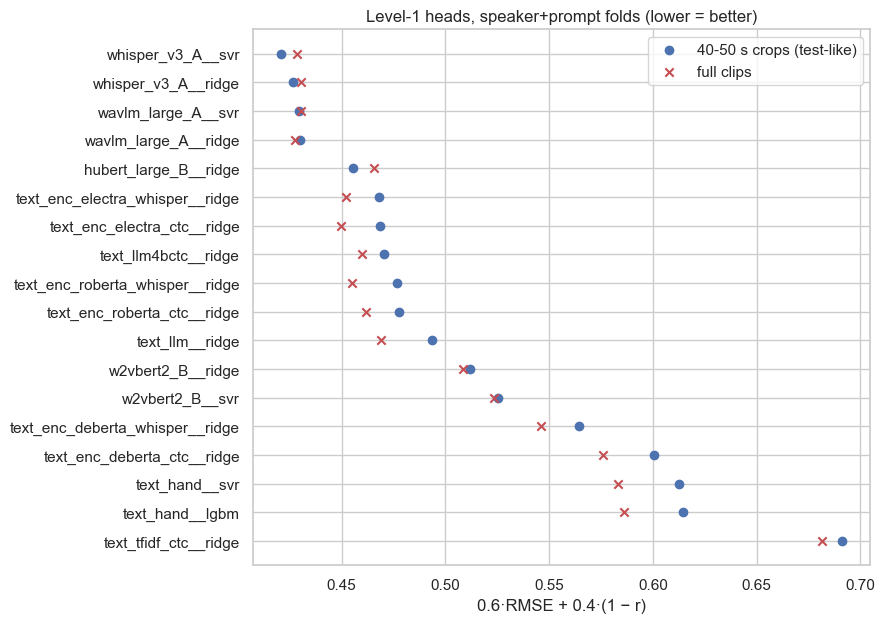

In [7]:
res_tab = pd.DataFrame(results).sort_values("composite_short").reset_index(drop=True)
res_tab.to_csv(OUT / "level1_results.csv", index=False)
display(res_tab[["name", "rmse_short", "pearson_short", "composite_short", "composite"]].round(4))
fig, ax = plt.subplots(figsize=(9, 0.3 * len(res_tab) + 1))
ax.scatter(res_tab.composite_short, range(len(res_tab)), label="40-50 s crops (test-like)")
ax.scatter(res_tab.composite, range(len(res_tab)), marker="x", c="#c44e52", label="full clips")
ax.set_yticks(range(len(res_tab))); ax.set_yticklabels(res_tab.name); ax.invert_yaxis(); ax.legend()
ax.set(title="Level-1 heads, speaker+prompt folds (lower = better)", xlabel="0.6·RMSE + 0.4·(1 − r)")
plt.tight_layout(); plt.show()